
### I. Perform DGE analysis after downloading the dataset from GEO and interpret the results



In [1]:
!pip install GEOparse pandas numpy scipy matplotlib seaborn
import GEOparse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind

print("All libraries imported successfully!")
gse = GEOparse.get_GEO("GSE143272", destdir=".")

print(gse)

16-Aug-2026 07:04:44 DEBUG utils - Directory . already exists. Skipping.
DEBUG:GEOparse:Directory . already exists. Skipping.
16-Aug-2026 07:04:44 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE143nnn/GSE143272/soft/GSE143272_family.soft.gz to ./GSE143272_family.soft.gz
INFO:GEOparse:Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE143nnn/GSE143272/soft/GSE143272_family.soft.gz to ./GSE143272_family.soft.gz


All libraries imported successfully!


100%|██████████| 33.0M/33.0M [00:00<00:00, 44.2MB/s]
16-Aug-2026 07:04:45 DEBUG downloader - Size validation passed
DEBUG:GEOparse:Size validation passed
16-Aug-2026 07:04:45 DEBUG downloader - Moving /tmp/tmp9b_e647l to /content/GSE143272_family.soft.gz
DEBUG:GEOparse:Moving /tmp/tmp9b_e647l to /content/GSE143272_family.soft.gz
16-Aug-2026 07:04:45 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE143nnn/GSE143272/soft/GSE143272_family.soft.gz
DEBUG:GEOparse:Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE143nnn/GSE143272/soft/GSE143272_family.soft.gz
16-Aug-2026 07:04:45 INFO GEOparse - Parsing ./GSE143272_family.soft.gz: 
INFO:GEOparse:Parsing ./GSE143272_family.soft.gz: 
16-Aug-2026 07:04:45 DEBUG GEOparse - DATABASE: GeoMiame
DEBUG:GEOparse:DATABASE: GeoMiame
16-Aug-2026 07:04:45 DEBUG GEOparse - SERIES: GSE143272
DEBUG:GEOparse:SERIES: GSE143272
16-Aug-2026 07:04:45 DEBUG GEOparse - PLATFORM: GPL10558
DEBUG:GEOparse:PLATFORM: GPL

<SERIES: GSE143272 - 142 SAMPLES, 1 d(s)>


In [2]:
print("Title:")
print(gse.metadata["title"][0])

print("\nSummary:")
print(gse.metadata["summary"][0])

print("\nOverall Design:")
print(gse.metadata["overall_design"][0])
sample = list(gse.gsms.values())[0]

print(sample.metadata.keys())
for key, value in sample.metadata.items():
    print(f"{key}: {value}")


Title:
Peripheral blood expression profiles of patients with epilepsy receiving and not receiving antiepileptic drug monotherapy and their differential response to the treatment.

Summary:
The aim here was to identify mRNA expression biomarkers associated with the disease epilepsy and the antiepileptic drug response. Gene expression profiles of drug-naïve patients with epilepsy were compared with that of healthy controls. The profiles were significantly different between the two groups as well as patients with different epilepsy types i.e. idiopathic, symptomatic and cryptogenic. Besides, patients showing differential response to antiepileptic monotherapies were also having differential blood gene expression profiles.

Overall Design:
Total RNA obtained from peripheral blood samples of 34 drug-naïve patients with epilepsy and 57 followed-up patients showing differential response to antiepileptic drug monotherapy along with 50 healthy subjects as control group.
dict_keys(['title', 'geo_

In [3]:
sample_info = []

for gsm_name, gsm in gse.gsms.items():
    title = gsm.metadata.get("title", [""])[0]
    description = gsm.metadata.get("description", [""])[0]

    # Extract 'Sex', 'age (in years)', 'ethnicity', 'epilepsy type', 'treatment', and 'drug response' from characteristics_ch1
    sex = "Unknown"
    age = "Unknown"
    ethnicity = "Unknown"
    epilepsy_type = "Unknown"
    treatment = "Unknown"
    drug_response = "Unknown"

    characteristics = gsm.metadata.get("characteristics_ch1", [])
    for char in characteristics:
        if "Sex:" in char:
            sex = char.split("Sex: ")[1]
        if "age (in years):" in char:
            age = char.split("age (in years): ")[1]
        if "ethnicity:" in char:
            ethnicity = char.split("ethnicity: ")[1]
        if "epilepsy type:" in char:
            epilepsy_type = char.split("epilepsy type: ")[1]
        if "treatment:" in char:
            treatment = char.split("treatment: ")[1]
        if "drug response:" in char:
            drug_response = char.split("drug response: ")[1]

    sample_info.append({
        "Sample": gsm_name,
        "Title": title,
        "Description": description,
        "Sex": sex,
        "age (in years)": age,
        "ethnicity": ethnicity,
        "epilepsy type": epilepsy_type,
        "treatment": treatment,
        "drug response": drug_response
    })

sample_df = pd.DataFrame(sample_info)

sample_df.head(10)
sample_df["Description"].value_counts()

,count
Description,
Healthy Control,51
Drug-naïve,34
Valproate Responder,16
Carbamazepine Responder,10
Valproate Non-responder,9
Carbamazepine Non-responder,9
Phenytoin Responder,7
Phenytoin Non-responder,6


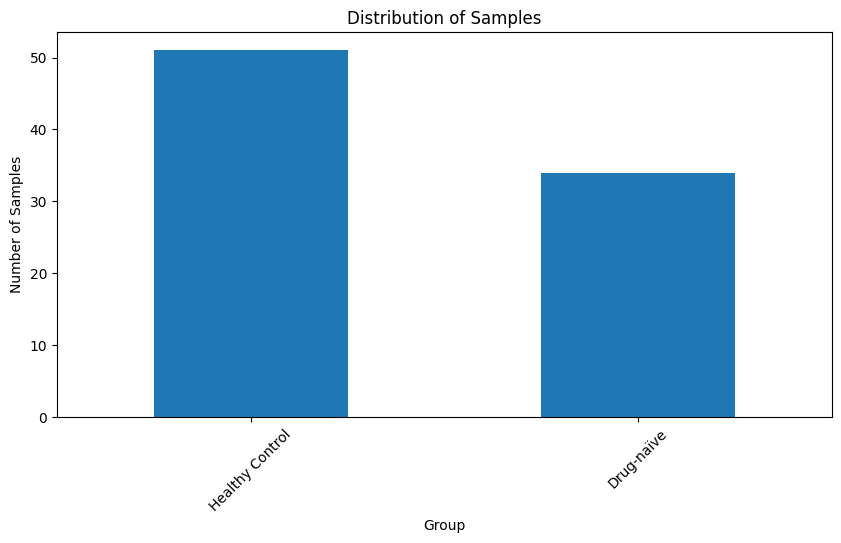

Controls: 51
Patients: 34


,GSM4255766,GSM4255767,GSM4255768,GSM4255769,GSM4255770,GSM4255771,GSM4255772,GSM4255773,GSM4255774,GSM4255775,...,GSM4255898,GSM4255899,GSM4255900,GSM4255901,GSM4255902,GSM4255903,GSM4255904,GSM4255905,GSM4255906,GSM4255907
count,13165.000000,13165.000000,13165.000000,13165.000000,13165.000000,13165.000000,13165.000000,13165.000000,13165.000000,13165.000000,...,13165.000000,13165.000000,13165.000000,13165.000000,13165.000000,13165.000000,13165.000000,13165.000000,13165.000000,13165.000000
mean,6.633764,6.675420,6.642817,6.628014,6.646827,6.636777,6.637102,6.642204,6.629138,6.631998,...,6.636081,6.646846,6.655666,6.647234,6.627853,6.635199,6.625964,6.658780,6.622462,6.630496
std,1.975923,2.010763,1.978294,1.965690,1.960679,1.996250,1.958906,1.983787,1.966179,1.967106,...,1.989911,1.976462,1.980369,1.966705,1.984857,1.959659,1.979844,1.949864,1.999165,1.961895
min,2.629514,2.391777,2.464689,2.007298,2.195687,1.696550,2.289709,1.473717,2.237868,2.199971,...,2.124048,2.113029,2.509025,2.288064,1.907166,-0.157394,1.797279,1.791145,1.990509,2.276374
25%,5.095004,5.113964,5.099637,5.097993,5.131680,5.085888,5.102418,5.104558,5.088565,5.089762,...,5.112822,5.117025,5.119866,5.124338,5.099812,5.118781,5.098748,5.167063,5.099013,5.113918
50%,6.147312,6.265253,6.168839,6.163985,6.229061,6.212349,6.209659,6.185265,6.148673,6.154712,...,6.197159,6.174499,6.197913,6.214266,6.180602,6.197659,6.179694,6.223987,6.172853,6.175709
75%,7.768992,7.850130,7.785574,7.771568,7.755982,7.783506,7.743260,7.764216,7.760352,7.768132,...,7.760343,7.777208,7.817395,7.774189,7.780394,7.757082,7.745936,7.788561,7.730878,7.730830
max,13.218380,13.238936,13.620592,13.232638,13.157838,13.260841,13.049924,14.379596,13.720725,13.402346,...,14.022102,13.591134,13.420674,13.051521,14.606754,13.104123,14.045613,13.363030,14.631784,13.825348


In [4]:
sample_df["Group"] = sample_df["Description"].replace({
    "Healthy Control": "Control",
    "Drug-naïve": "Epilepsy"
})
sample_df = sample_df[sample_df["Group"].isin(["Control", "Epilepsy"])]
# Count samples in each group
sample_df["Description"].value_counts().to_frame("count")
import matplotlib.pyplot as plt

sample_df["Description"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Distribution of Samples")
plt.xlabel("Group")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.show()
controls = sample_df[sample_df["Description"]=="Healthy Control"]

patients = sample_df[sample_df["Description"]!="Healthy Control"]

print("Controls:", len(controls))
print("Patients:", len(patients))
sample_df["Sex"].value_counts()
pd.crosstab(sample_df["Description"], sample_df["Sex"])
sample_df["age (in years)"] = sample_df["age (in years)"].astype(float)
sample_df.groupby("Description")["age (in years)"].describe()
sample_df.groupby("Description")["age (in years)"].mean().sort_values()
sample_df["ethnicity"].value_counts()
sample_df["epilepsy type"].value_counts()
sample_df["drug response"].value_counts()
sample_df["treatment"].value_counts()
pd.crosstab(
    sample_df["treatment"],
    sample_df["drug response"]
)
pd.crosstab(
    sample_df["epilepsy type"],
    sample_df["treatment"]
)
sample_df.to_csv("GSE143272_metadata.csv", index=False)
expression = pd.DataFrame({
    gsm_name: gsm.table.set_index("ID_REF")["VALUE"]
    for gsm_name, gsm in gse.gsms.items()
})
expression.shape
expression.to_csv("GSE143272_expression_matrix.csv")
expression.head()
expression.describe()

In [5]:
print(len(sample_df))
print(sample_df["Description"].value_counts())

85
Description
Healthy Control    51
Drug-naïve         34
Name: count, dtype: int64


In [6]:
# Select only Healthy Controls and Drug-naïve samples

selected_samples = sample_df[
    sample_df["Description"].isin(["Healthy Control", "Drug-naïve"])
].copy()

print(selected_samples["Description"].value_counts())

control_ids = selected_samples[
    selected_samples["Description"]=="Healthy Control"
]["Sample"].tolist()

patient_ids = selected_samples[
    selected_samples["Description"]=="Drug-naïve"
]["Sample"].tolist()

print(len(control_ids))
print(len(patient_ids))

expr = expression[control_ids + patient_ids]

expr.shape

Description
Healthy Control    51
Drug-naïve         34
Name: count, dtype: int64
51
34


(13165, 85)

(0, 4)
(2322, 4)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

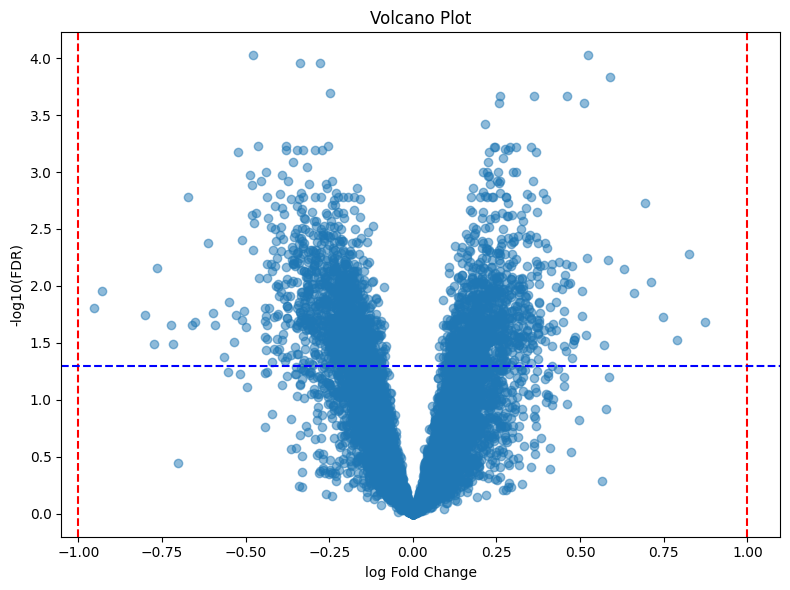

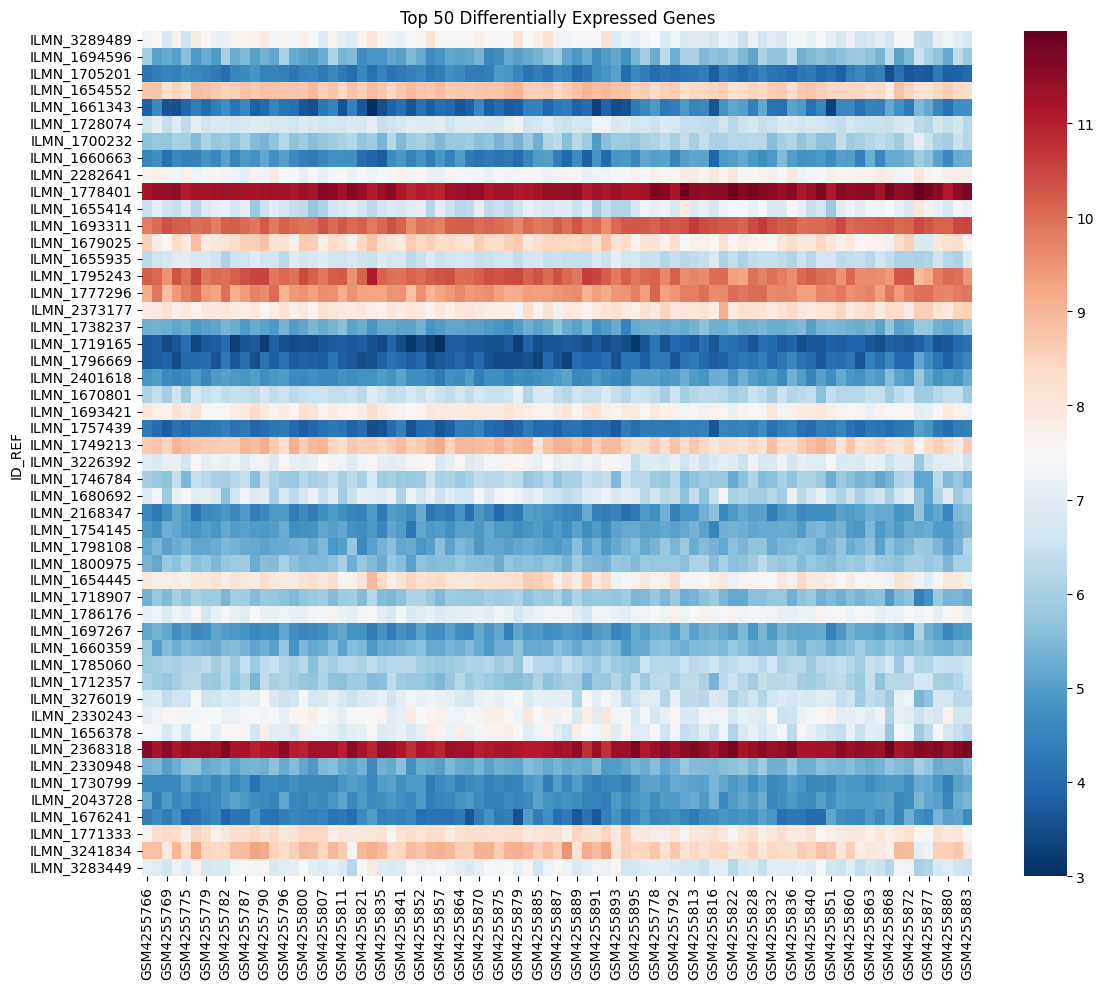

In [9]:

!pip install statsmodels

results = []

for gene in expr.index:

    control = expr.loc[gene, control_ids].astype(float)

    patient = expr.loc[gene, patient_ids].astype(float)

    t_stat, p_value = ttest_ind(patient,
                                control,
                                equal_var=False)

    logFC = patient.mean() - control.mean()

    results.append([gene, logFC, p_value])

    import pandas as pd

deg = pd.DataFrame(
    results,
    columns=["Gene","logFC","P-value"]
)

deg.head()
from statsmodels.stats.multitest import multipletests

deg["Adj_P"] = multipletests(
    deg["P-value"],
    method="fdr_bh"
)[1]
significant = deg[
    (deg["Adj_P"]<0.05) &
    (abs(deg["logFC"])>1)
]

print(significant.shape)

significant.head()
significant = deg[
    deg["Adj_P"]<0.05
]

print(significant.shape)
significant = significant.sort_values(
    by="Adj_P"
)

significant.head(20)

significant.to_csv(
    "Differentially_Expressed_Genes.csv",
    index=False
)
from google.colab import files

files.download("Differentially_Expressed_Genes.csv")
import numpy as np
import matplotlib.pyplot as plt

deg["minusLog10P"] = -np.log10(deg["Adj_P"])

plt.figure(figsize=(8,6))

plt.scatter(
    deg["logFC"],
    deg["minusLog10P"],
    alpha=0.5
)

plt.xlabel("log Fold Change")
plt.ylabel("-log10(FDR)")
plt.title("Volcano Plot")

plt.axvline(1, color='red', linestyle='--')
plt.axvline(-1, color='red', linestyle='--')
plt.axhline(-np.log10(0.05), color='blue', linestyle='--')

plt.tight_layout()
plt.savefig("volcano_plot.png", dpi=300, bbox_inches="tight")
plt.show()

import seaborn as sns

top50 = significant.head(50)["Gene"]

heatmap_data = expr.loc[top50]

plt.figure(figsize=(12,10))

sns.heatmap(
    heatmap_data,
    cmap="RdBu_r"
)

plt.title("Top 50 Differentially Expressed Genes")
plt.tight_layout()
plt.savefig("heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

#STEPS:
1. Library Installation and Data Loading: Essential libraries like GEOparse, pandas, numpy, scipy, matplotlib, and seaborn are installed and imported. The GSE143272 dataset is then downloaded and loaded using GEOparse.get_GEO.

2. Metadata Extraction and Cleaning:
*   Key metadata (title, summary, overall design) and sample-specific metadata are extracted from the gse object.

*   A sample_df DataFrame is created to store sample information, including 'Sample', 'Title', 'Description', 'Sex', 'age (in years)', 'ethnicity', 'epilepsy type', 'treatment', and 'drug response', all extracted from the characteristics_ch1 field.

3. Sample Grouping and Initial Analysis:

* A 'Group' column is added to sample_df, categorizing 'Healthy Control' as 'Control' and 'Drug-naïve' as 'Epilepsy'.
* The sample_df is filtered to include only 'Control' and 'Epilepsy' groups.
* Various metadata distributions (e.g., sample counts, sex, age, ethnicity, epilepsy type, drug response, treatment) are analyzed and visualized.
* The expression DataFrame is created from the raw gene expression data, indexed by gene IDs.

4. Filtering Expression Data for DGE Analysis:

* sample_df is further filtered to select only 'Healthy Control' and 'Drug-naïve' samples.
* Control and patient sample IDs are extracted.
* The expression DataFrame (expr) is subsetted to include only these selected control and patient samples.

5. Differential Gene Expression (DGE) Analysis:

* A loop iterates through each gene in the expr DataFrame.
* For each gene, t-tests are performed to compare expression levels between patient and control groups using scipy.stats.ttest_ind.
* Log Fold Change (logFC) is calculated as the difference in mean expression between patient and control groups.
* Results (Gene, logFC, P-value) are collected into a DataFrame deg.
* Adjusted p-values (Adj_P) are calculated using the Benjamini-Hochberg (FDR) method via statsmodels.stats.multitest.multipletests to correct for multiple comparisons.
* Significant genes are identified based on Adj_P < 0.05 and |logFC| > 1 (initially) and then only Adj_P < 0.05.
* The significant genes are sorted by adjusted p-value and saved to a CSV file (Differentially_Expressed_Genes.csv).

6. Visualization of DGE Results:

* A Volcano Plot is generated to visualize logFC against -log10(Adjusted P-value), highlighting genes with significant expression changes.
* A Heatmap is generated for the top 50 differentially expressed genes, showing their expression patterns across the selected control and patient samples.

##Written analysis:
Differential gene expression analysis was performed using the GEO dataset GSE143272, comparing 34 drug-naïve epilepsy patients with 51 healthy controls.

Welch's t-test followed by Benjamini–Hochberg false discovery rate correction identified 2,322 significantly differentially expressed genes (FDR < 0.05).

The volcano plot illustrates the distribution of significantly upregulated and downregulated genes, while the heatmap of the top 50 differentially expressed genes demonstrates distinct expression patterns between epilepsy patients and healthy controls.

These genes may represent potential biomarkers and provide insights into the molecular mechanisms underlying epilepsy.